In [1]:
import seaborn
import pandas
import geopandas
import pysal
import numpy
import mapclassify
import matplotlib.pyplot as plt
from pysal.explore import esda
from pysal.lib import weights

c:\Users\User\.ipython\.venv\Lib\site-packages\spaghetti\network.py:41: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)


In [2]:
import os
# Check current working directory
print("Current working directory:", os.getcwd())

# List files in the current directory
print("Files in directory:", os.listdir())

Current working directory: c:\Users\User\.ipython\.venv\geopandas-coures-files\geopandas-coures-files\Spatial_Data_Analysis
Files in directory: ['Analyis2.ipynb', 'Analysis1.ipynb', 'Analysis3.ipynb', 'Analysis4.ipynb', 'Anlysis5.ipynb', 'brexit_vote.csv', 'chart.png', 'choropleth_map.png', 'correlation.png', 'distribution_map.png', 'Distribution_Pattern.png', 'DSd.cpg', 'DSd.dbf', 'DSd.prj', 'DSd.sbn', 'DSd.sbx', 'DSd.shp', 'DSd.shp.xml', 'DSd.shx', 'interpolation_distribution_map2.png', 'japan_distribution_map.png', 'japan_distribution_map2.png', 'japan_distribution_map3.png', 'japan_distribution_map4.png', 'Kandy_data.cpg', 'Kandy_data.dbf', 'Kandy_data.prj', 'Kandy_data.sbn', 'Kandy_data.sbx', 'Kandy_data.shp', 'Kandy_data.shp.xml', 'Kandy_data.shx', 'kde_rugplot.png', 'local_authority_districts.geojson', 'mis.ipynb', 'morans_correlation.png', 'Nuwara_Data.cpg', 'Nuwara_Data.dbf', 'Nuwara_Data.prj', 'Nuwara_Data.sbn', 'Nuwara_Data.sbx', 'Nuwara_Data.shp', 'Nuwara_Data.shp.xml', 'Nu

In [3]:
pci_df = geopandas.read_file(
    "uscountypcincome.gpkg"
)
pci_df.columns

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'GeoFIPS', 'GeoName', 'Region',
       'TableName', 'LineCode', 'Descriptio', 'Unit', '1969', '1970', '1971',
       '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980',
       '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989',
       '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998',
       '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007',
       '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016',
       '2017', 'index', 'IndustryCl', 'Descript_1', 'geometry'],
      dtype='object')

In [4]:
(3076, 77)

(3076, 77)

In [5]:
pci_df.query('NAME == "Jackson" & STATEFP == "28"').loc[
    :, "1969":"1979"
]

,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979
1417,2957,3121,3327,3939,4203,4547,5461,5927,6315,6619,6967


Global inequlaity

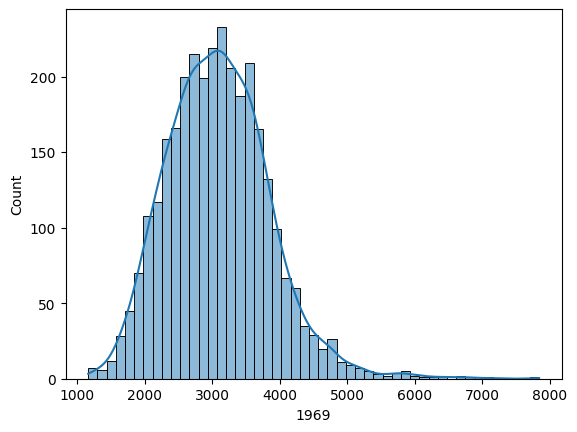

In [6]:
seaborn.histplot(x=pci_df["1969"], kde=True);

In [8]:
pci_df = pci_df.to_crs(
    # Albers Equal Area North America
    epsg=5070
)

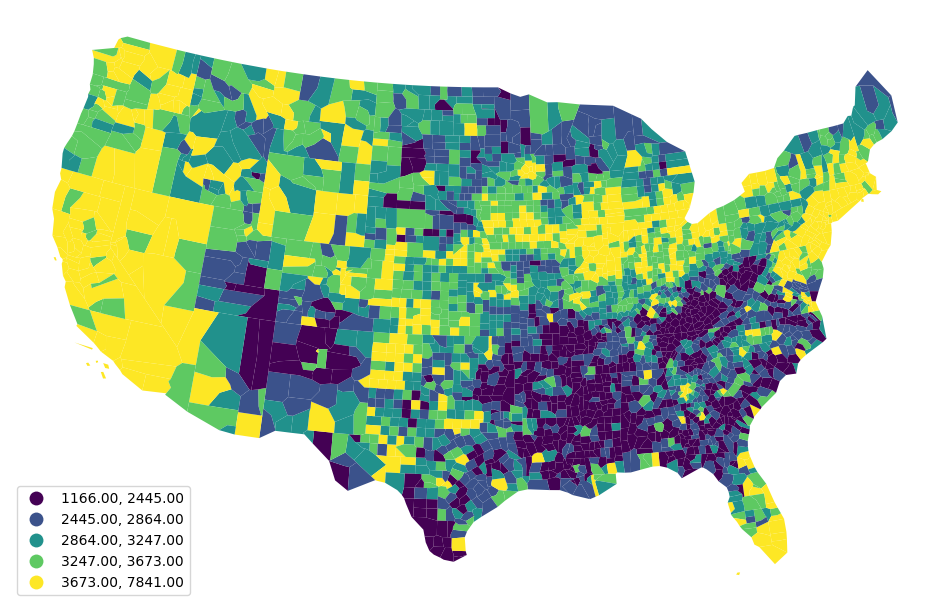

In [9]:
ax = pci_df.plot(
    column="1969",
    scheme="Quantiles",
    legend=True,
    edgecolor="none",
    legend_kwds={"loc": "lower left"},
    figsize=(12, 12),
)
ax.set_axis_off()
plt.show()

In [ ]:
top20, bottom20 = pci_df["1969"].quantile([0.8, 0.2])
#One commonly used measure of inequality in a distribution is the so-called 20:20 ratio, which is defined as the ratio of the incomes at the 80th percentile over that at the 20th percentile:

In [11]:
top20 / bottom20

1.5022494887525562

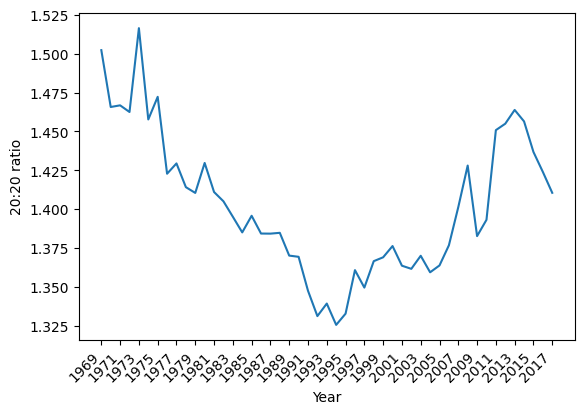

In [12]:
def ineq_20_20(values):
    top20, bottom20 = values.quantile([0.8, 0.2])
    return top20 / bottom20


# Generate range of strings from 1969 to 2018
years = numpy.arange(1969, 2018).astype(str)
# Compute 20:20 ratio for every year
ratio_2020 = pci_df[years].apply(ineq_20_20, axis=0)
# Plot evolution of 20:20 ratio
ax = plt.plot(years, ratio_2020)

# Grab figure generated in the plot
figure = plt.gcf()
# Replace tick labels with every other year
plt.xticks(years[::2])
# Set vertical label
plt.ylabel("20:20 ratio")
# Set horizontal label
plt.xlabel("Year")
# Rotate year labels
figure.autofmt_xdate(rotation=45)

plt.show()

In [ ]:
#Gini index

In [13]:
from pysal.explore import inequality

In [14]:
n = len(pci_df)
share_of_population = numpy.arange(1, n + 1) / n

In [15]:
incomes = pci_df["1969"].sort_values()

In [17]:
shares = incomes / incomes.sum()

In [18]:
cumulative_share = shares.cumsum()

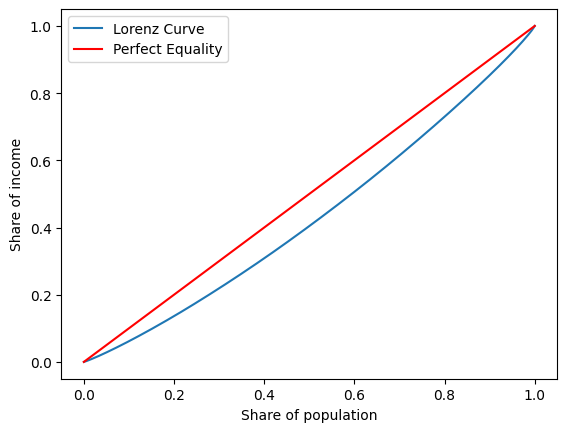

In [19]:
# Generate figure with one axis
f, ax = plt.subplots()
# Plot Lorenz Curve
ax.plot(share_of_population, cumulative_share, label="Lorenz Curve")
# Plot line of perfect equality
ax.plot((0, 1), (0, 1), color="r", label="Perfect Equality")
# Label horizontal axis
ax.set_xlabel("Share of population")
# Label vertical axis
ax.set_ylabel("Share of income")
# Add legend
ax.legend()

plt.show()

In [20]:
def lorenz(y):
    y = numpy.asarray(y)
    incomes = numpy.sort(y)
    income_shares = (incomes / incomes.sum()).cumsum()
    N = y.shape[0]
    pop_shares = numpy.arange(1, N + 1) / N
    return pop_shares, income_shares

In [21]:
lorenz(pci_df["1969"])

(array([3.25097529e-04, 6.50195059e-04, 9.75292588e-04, ...,
        9.99349805e-01, 9.99674902e-01, 1.00000000e+00]),
 array([1.22486441e-04, 2.52956561e-04, 3.83636778e-04, ...,
        9.98429316e-01, 9.99176315e-01, 1.00000000e+00]))

In [22]:
lorenz_curves = pci_df[years].apply(lorenz, axis=0)

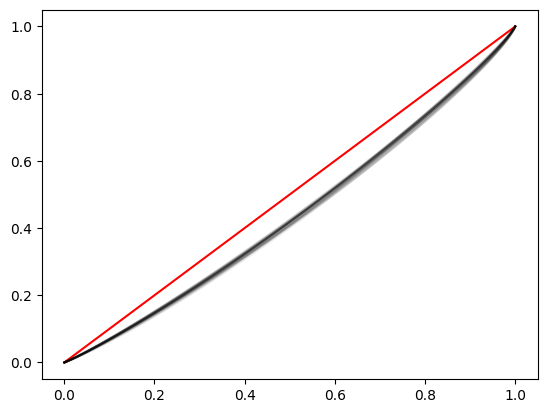

In [23]:
# Set up figure with one axis
f, ax = plt.subplots()
# Plot line of perfect equality
ax.plot((0, 1), (0, 1), color="r")
# Loop over every year in the series
for year in lorenz_curves.columns:
    # Extract the two arrays or each dimension
    year_pop_shares, year_inc_shares = lorenz_curves[year].values
    # Plot Lorenz curve for a given year
    ax.plot(year_pop_shares, year_inc_shares, color="k", alpha=0.05)

In [24]:
g69 = inequality.gini.Gini(pci_df["1969"].values)

In [25]:
g69.g

0.13556175504269904

In [26]:
def gini_by_col(column):
    return inequality.gini.Gini(column.values).g

In [27]:
inequalities = (
    pci_df[years].apply(gini_by_col, axis=0).to_frame("gini")
)

In [28]:
inequalities.head()

,gini
1969,0.135562
1970,0.130076
1971,0.128540
1972,0.129126
1973,0.142166


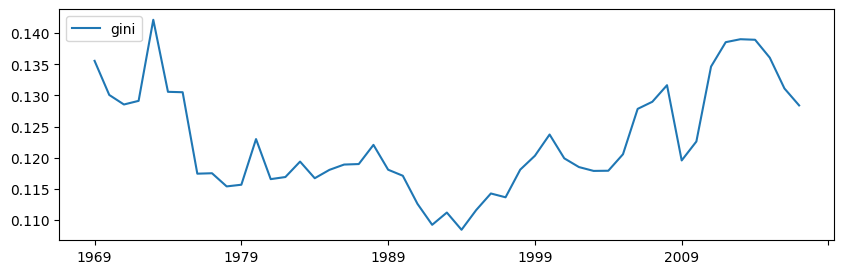

In [29]:
inequalities.plot(figsize=(10, 3));

In [30]:
#Theil’s index
def theil(column):
    return inequality.theil.Theil(column.values).T


inequalities["theil"] = pci_df[years].apply(theil, axis=0)

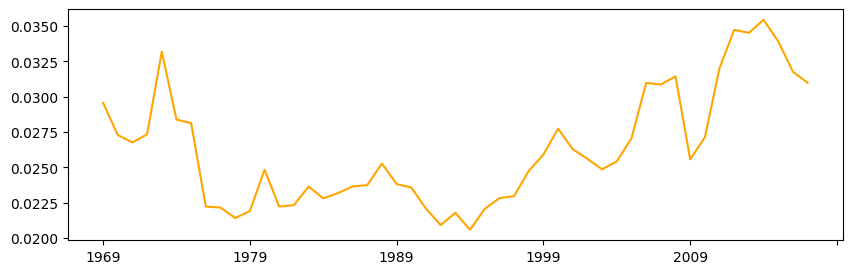

In [31]:
inequalities["theil"].plot(color="orange", figsize=(10, 3));

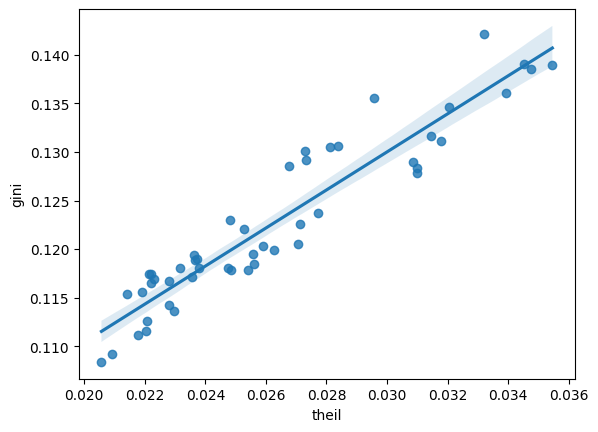

In [32]:
_ = seaborn.regplot(x="theil", y="gini", data=inequalities)

To see this, we first need to express the relationships between the two types of inequality

In [33]:
#Spatial autocorrelation
wq = weights.Queen.from_dataframe(pci_df)

C:\Users\User\AppData\Local\Temp\ipykernel_13348\3162326897.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq = weights.Queen.from_dataframe(pci_df)


In [35]:
def moran_by_col(y, w=wq):
    mo = esda.Moran(y, w=w)
    mo_s = pandas.Series(
        {"I": mo.I, "I-P value": mo.p_sim},
    )
    return mo_s

In [36]:
moran_stats = pci_df[years].apply(moran_by_col, axis=0).T

moran_stats.head()

,I,I-P value
1969,0.649090,0.001
1970,0.647438,0.001
1971,0.626546,0.001
1972,0.606760,0.001
1973,0.640226,0.001


In [37]:
inequalities = inequalities.join(moran_stats)

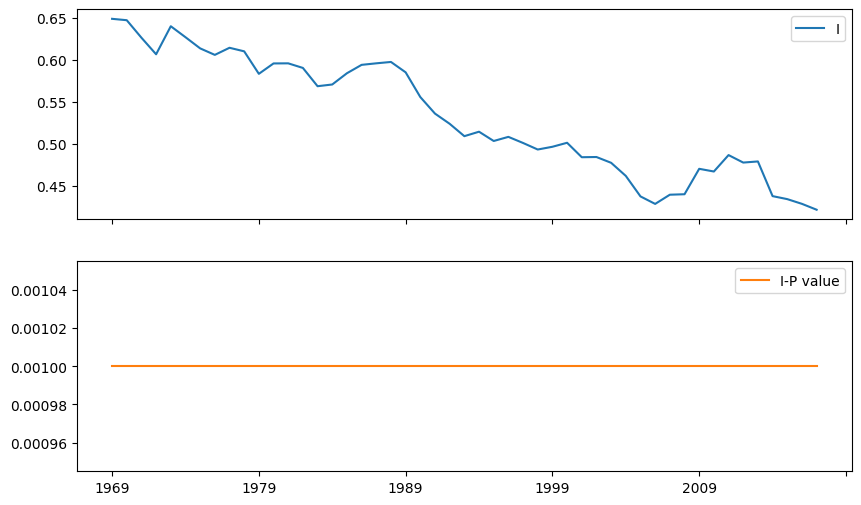

In [38]:
inequalities[["I", "I-P value"]].plot(subplots=True, figsize=(10, 6))
plt.show()

In [39]:
#Regional decomposition of inequality
region_names = {
    1: "New England",
    2: "Mideast",
    3: "Great Lakes",
    4: "Plains",
    5: "Southeast",
    6: "Southwest",
    7: "Rocky Mountain",
    8: "Far West",
}

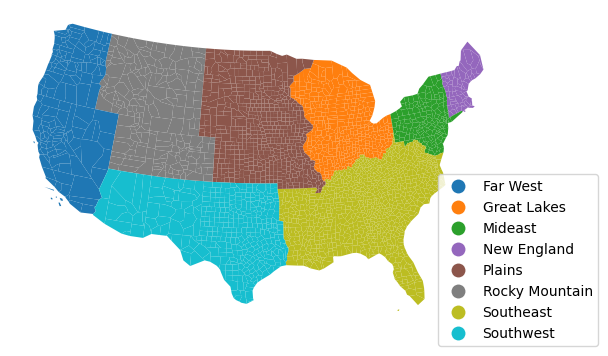

In [40]:
ax = pci_df.assign(Region_Name=pci_df.Region.map(region_names)).plot(
    "Region_Name",
    linewidth=0,
    legend=True,
    categorical=True,
    legend_kwds=dict(bbox_to_anchor=(1.2, 0.5)),
)
ax.set_axis_off();

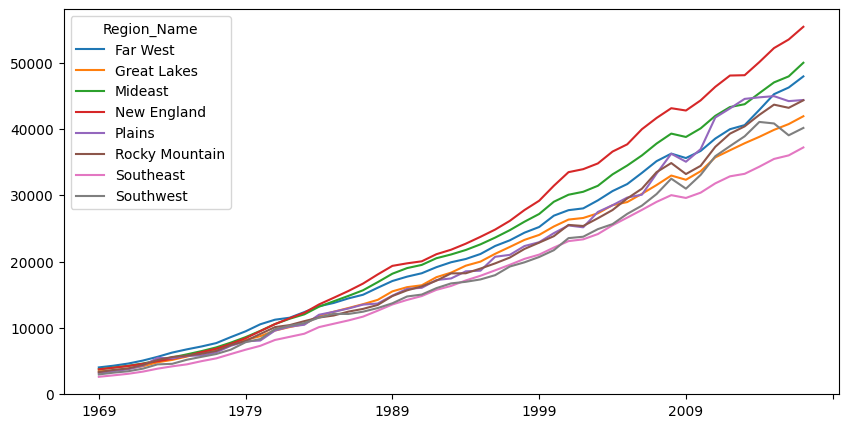

In [44]:
rmeans = (
    pci_df.assign(
        # Create column with region name for each county
        Region_Name=pci_df.Region.map(region_names)
    )
    .groupby(
        # Group counties by region name
        by="Region_Name"
    )[years]  # Select only the year columns for aggregation
    .mean()
)
rmeans.T.plot.line(figsize=(10, 5));

In [45]:
theil_dr = inequality.theil.TheilD(
    pci_df[years].values, pci_df.Region
)

In [46]:
theil_dr.bg

array([0.00914353, 0.00822696, 0.00782675, 0.00768201, 0.01022634,
       0.0081274 , 0.00783943, 0.00572543, 0.00560271, 0.0054971 ,
       0.00511791, 0.00566001, 0.00486877, 0.00466134, 0.00474425,
       0.00424528, 0.00428434, 0.00453503, 0.00465829, 0.00456699,
       0.00467363, 0.00412391, 0.00366334, 0.00342112, 0.00327131,
       0.00312475, 0.00326071, 0.00359733, 0.00327591, 0.00363014,
       0.00382409, 0.00436261, 0.00399156, 0.00402506, 0.00397   ,
       0.00394649, 0.00353368, 0.00362698, 0.00400508, 0.00449814,
       0.0043533 , 0.00470988, 0.0063954 , 0.00642426, 0.00694236,
       0.00644971, 0.00591871, 0.00554072, 0.00528702])

In [47]:
inequalities["theil_between"] = theil_dr.bg
inequalities["theil_within"] = theil_dr.wg

In [48]:
inequalities["theil_between_share"] = (
    inequalities["theil_between"] / inequalities["theil"]
)

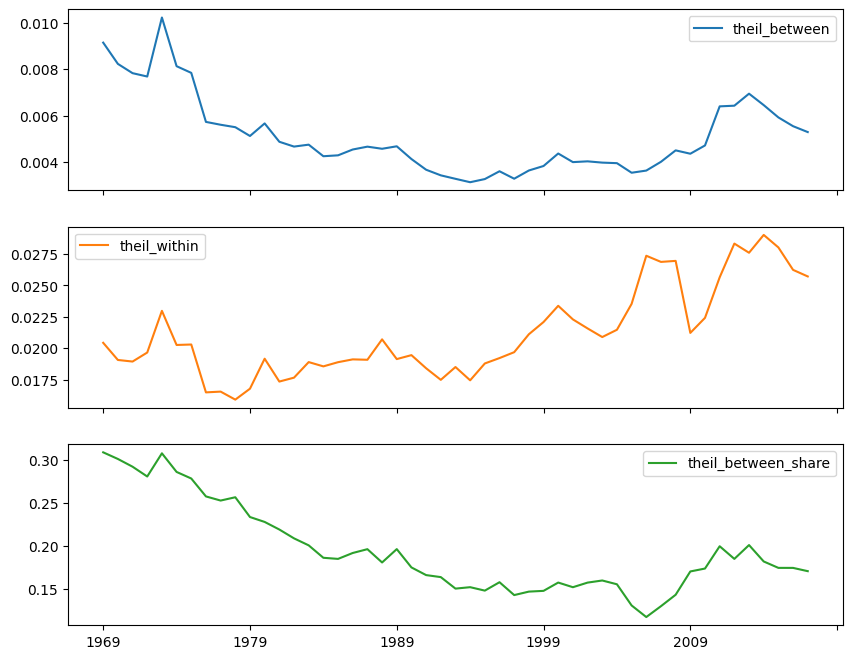

In [49]:
inequalities[
    ["theil_between", "theil_within", "theil_between_share"]
].plot(subplots=True, figsize=(10, 8));

In [50]:
#Spatializing classic measures

In [51]:
from inequality.gini import Gini_Spatial

In [52]:
wq.transform = "B"

In [53]:
gs69 = Gini_Spatial(pci_df["1969"], wq)

In [54]:
gs69.g

0.13556175504269904

In [55]:
gs69.wcg_share

0.13541750749645268

In [56]:
gs69.p_sim

0.01

In [57]:
def gini_spatial_by_col(incomes, weights):
    gs = Gini_Spatial(incomes, weights)
    denom = 2 * incomes.mean() * weights.n ** 2
    near_diffs = gs.wg / denom
    far_diffs = gs.wcg / denom
    out = pandas.Series(
        {
            "gini": gs.g,
            "near_diffs": near_diffs,
            "far_diffs": far_diffs,
            "p_sim": gs.p_sim,
        }
    )
    return out

In [58]:
%%time
spatial_gini_results = (
    pci_df[years].apply(gini_spatial_by_col, weights=wq).T
)

CPU times: total: 2min 18s
Wall time: 2min 21s


In [59]:
spatial_gini_results.head()
(spatial_gini_results.p_sim < 0.05).mean()
wq.pct_nonzero

0.19385366975502275

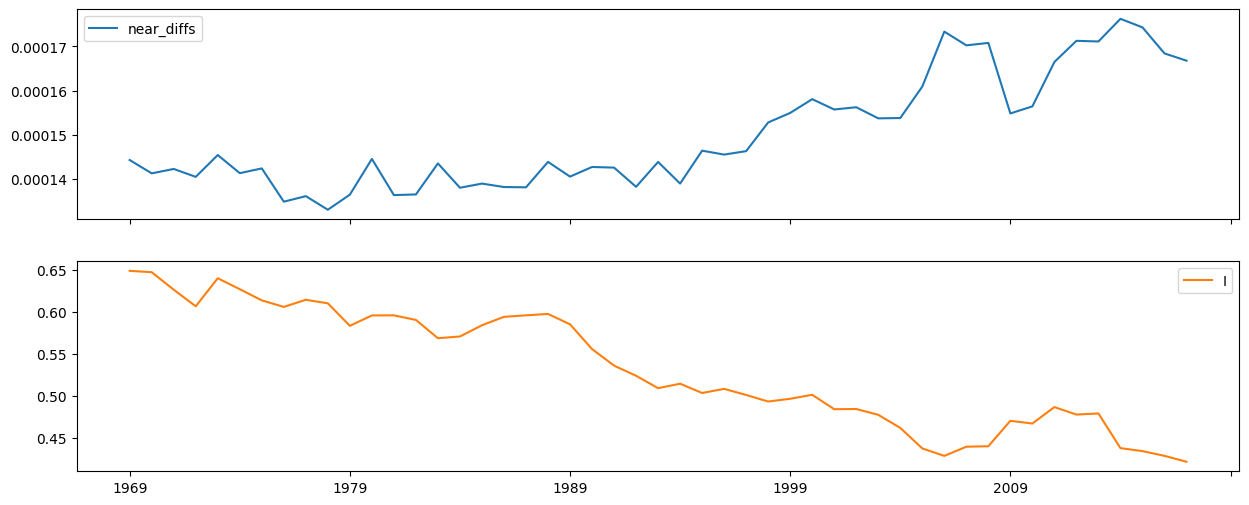

In [60]:
inequalities["near_diffs"] = spatial_gini_results.near_diffs

inequalities[["near_diffs", "I"]].plot.line(
    subplots=True, figsize=(15, 6)
);